In [2]:
import numpy as np
import matplotlib.pyplot as plt

### Covariance/correlation example, x and y have common component  + random noise in y 

assume x and y represent sea level in units of cm, time in units of days

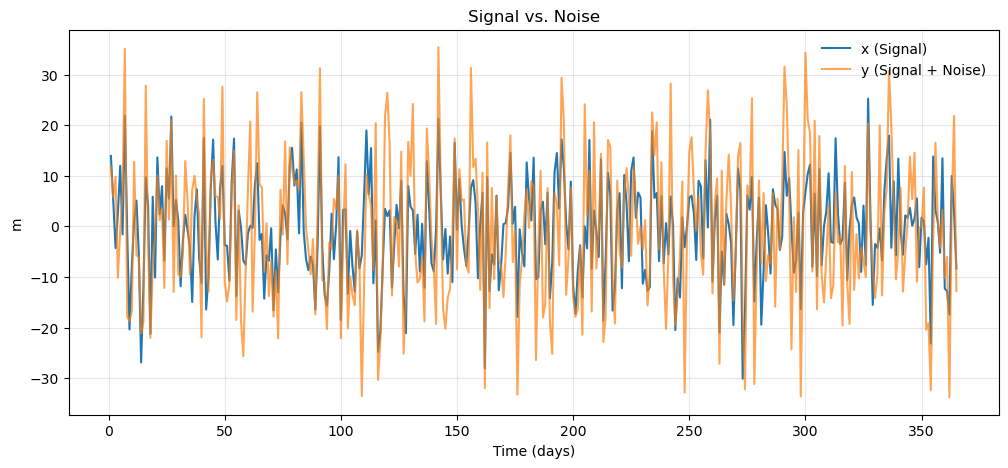

In [4]:
sigma_s = 10   # Std of the signal
sigma_n = 10   # Std of the noise
npts = 365     # one yr of ddaily data

# np.random.normal(mean, std, size) is the equivalent of normrnd
x = np.random.normal(0, sigma_s, npts)
y = x + np.random.normal(0, sigma_n, npts)
t = np.arange(1, npts + 1)

# 3. Create Figure 1
plt.figure(figsize=(12, 5))

plt.plot(t, x, label='x (Signal)', linewidth=1.5)
plt.plot(t, y, label='y (Signal + Noise)', alpha=0.7)

# Formatting
plt.legend(frameon=False) 
plt.xlabel('Time (days)')
plt.ylabel('m')
plt.title('Signal vs. Noise')

plt.grid(True, alpha=0.3)

plt.show()

<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
<>:17: SyntaxWarning: invalid escape sequence '\m'
<>:20: SyntaxWarning: invalid escape sequence '\c'
<>:30: SyntaxWarning: invalid escape sequence '\c'
/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_91093/1414469220.py:17: SyntaxWarning: invalid escape sequence '\m'
  ax1.plot(t, xy_product, label='$(x-\mu_x)(y-\mu_y)$')
/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_91093/1414469220.py:20: SyntaxWarning: invalid escape sequence '\c'
  ax1.set_ylabel('$x \cdot y$ anomaly product ($m^2$)', fontsize=14)
/var/folders/7q/04p1sn755vg5x39skt2hykjh0000gn/T/ipykernel_91093/1414469220.py:30: SyntaxWarning: invalid escape sequence '\c'
  ax2.set_ylabel('Normalized $x \cdot y$ product', fontsize=14)


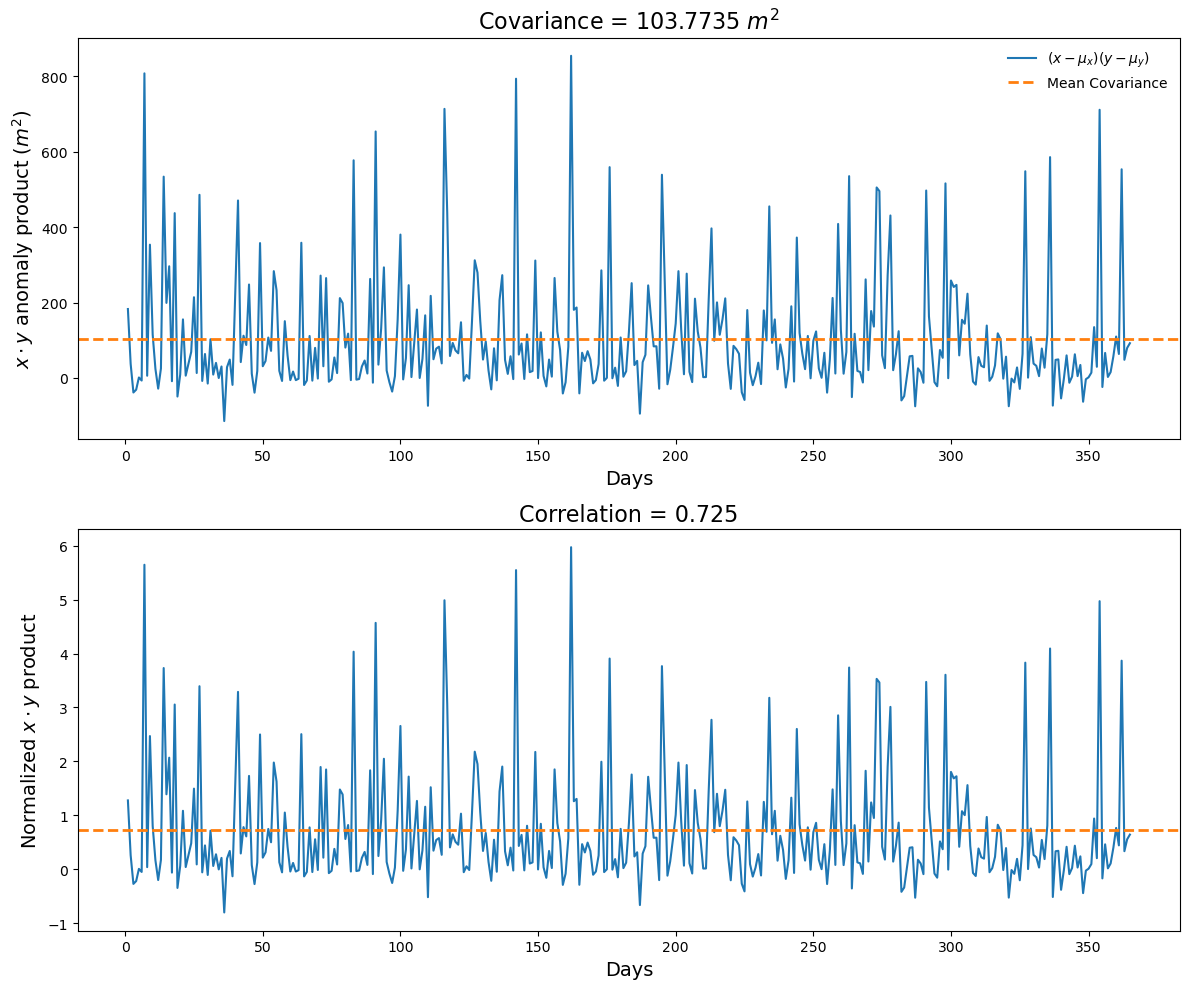

In [7]:

# compute Covariance manually
x_anom = x - np.mean(x)
y_anom = y - np.mean(y)
xy_product = x_anom * y_anom
cov_manual = np.sum(xy_product) / (npts - 1)

# compute correlation
# cor = Cov(x,y) / (std(x) * std(y))
std_x = np.std(x, ddof=1) # ddof=1 matches MATLAB's (N-1) normalization
std_y = np.std(y, ddof=1)
cor_manual = cov_manual / (std_x * std_y)

# create the plots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

# Covariance
ax1.plot(t, xy_product, label='$(x-\mu_x)(y-\mu_y)$')
ax1.axhline(cov_manual, color='C1', linestyle='--', linewidth=2, label='Mean Covariance')
ax1.set_title(f'Covariance = {cov_manual:.4f} $m^2$', fontsize=16)
ax1.set_ylabel('$x \cdot y$ anomaly product ($m^2$)', fontsize=14)
ax1.set_xlabel('Days', fontsize=14)
ax1.legend(frameon=False)

# Correlation
# Normalizing the product by the standard deviations
norm_xy_product = xy_product / (std_x * std_y)
ax2.plot(t, norm_xy_product)
ax2.axhline(cor_manual, color='C1', linestyle='--', linewidth=2)
ax2.set_title(f'Correlation = {cor_manual:.3f}', fontsize=16)
ax2.set_ylabel('Normalized $x \cdot y$ product', fontsize=14)
ax2.set_xlabel('Days', fontsize=14)



plt.tight_layout()
plt.show()

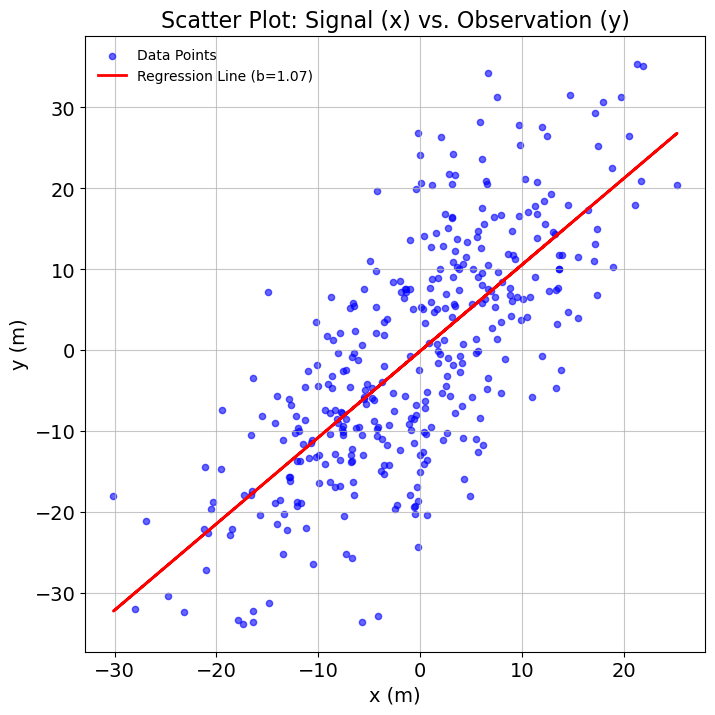

Manual Covariance: 103.7735
NumPy Covariance Matrix:
[[ 97.32611304 103.77353449]
 [103.77353449 210.41861018]]
Correlation (rho): 0.7252
R-squared (rho^2): 0.5258


In [9]:
from scipy import stats # for linear regression

plt.figure(figsize=(8, 8))

plt.scatter(x, y, s=20, c='blue', alpha=0.6,  label='Data Points')

# Add the Regression Line (Prep for Part 6 of the assignment)
# SLA = b * ONI
slope, intercept, r, p, std_err = stats.linregress(x, y)
line = slope * x + intercept
plt.plot(x, line, color='red', linewidth=2, label=f'Regression Line (b={slope:.2f})')

# Formatting
plt.grid(True, alpha=0.7)
plt.xlabel('x (m)', fontsize=14)
plt.ylabel('y (m)', fontsize=14)
plt.title('Scatter Plot: Signal (x) vs. Observation (y)', fontsize=16)
plt.gca().tick_params(labelsize=14)
plt.legend(frameon=False)

plt.show()

# print stats  
# np.corr and np.cov 

print(f"Manual Covariance: {cov_manual:.4f}")
print(f"NumPy Covariance Matrix:\n{np.cov(x, y)}") # Equivalent to cov(x,y)
print(f"Correlation (rho): {r:.4f}")         # Equivalent to rho = corr(x,y)
print(f"R-squared (rho^2): {r**2:.4f}")      # Equivalent to rho^2

#### Covariance with progressively higher random noise in y

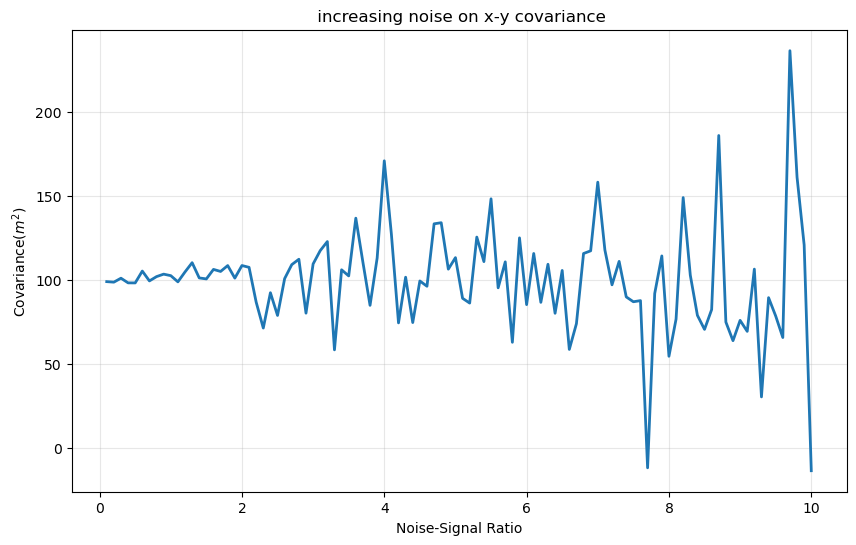

In [ ]:
sigma_s = 10
npts = 365

x= np.random.normal(0, sigma_s, npts)

# generate empty arrays for the loop
C = np.zeros(100)
noise_signal = np.zeros(100)

# loop with incr. noise
for j in range(1,101):
    sigma_n = j
    y = x + np.random.normal(0, sigma_n, npts)
    # covariance
    C[j-1] = np.sum(x * y) / (npts - 1)
    # noise-signal ratio
    noise_signal[j-1] = sigma_n / sigma_s

plt.figure(figsize=(10,6))
plt.plot(noise_signal, C, linewidth=2)

plt.title(' increasing noise on x-y covariance')
plt.xlabel('Noise-Signal Ratio')
plt.ylabel('Covariance($m^2$)')
plt.grid(True, alpha=0.3)


#### Correlation with progressively higher random noise in y 

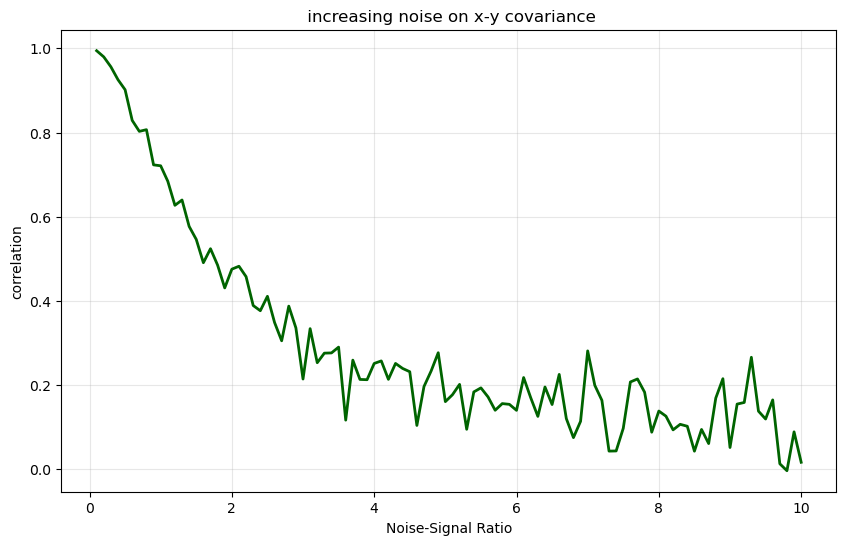

In [13]:
sigma_s = 10
npts = 365
x= np.random.normal(0, sigma_s, npts)

rho = np.zeros(100)
noise_signal = np.zeros(100)

# loop with incr. noise
for j in range(1,101):
    sigma_n = j
    y = x + np.random.normal(0, sigma_n, npts)
    # correlation
    # np.corrcoef retrns a 2x2 matrix, we take the off diagonal value [0,1]
    rho[j-1] = np.corrcoef(x,y)[0,1]
    # noise-signal ratio
    noise_signal[j-1] = sigma_n / sigma_s

plt.figure(figsize=(10, 6))
plt.plot(noise_signal, rho, linewidth=2, color='darkgreen')


plt.title(' increasing noise on x-y covariance')
plt.xlabel('Noise-Signal Ratio')
plt.ylabel('correlation')
plt.grid(True, alpha=0.3)



#### Regression with progressively added noise in y

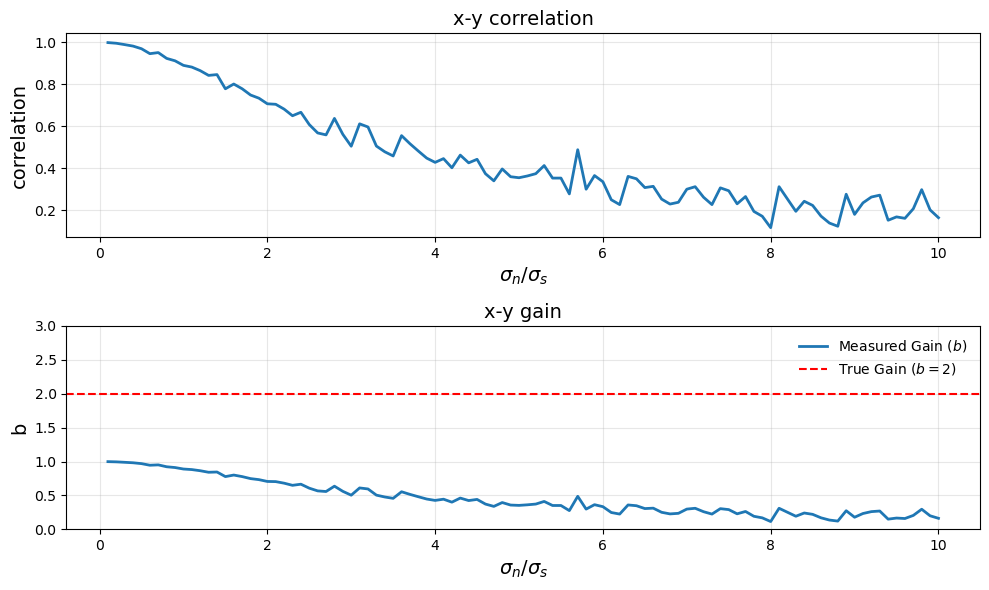

In [16]:
sigma_s=10
npts=365
x=np.random.normal(0, sigma_s, npts)

rho = np.zeros(100)
b = np.zeros(100)
noise_signal = np.zeros(100)

# loop with incr. noise
for j in range(1,101):
    sigma_n = j
    y = 2*x + np.random.normal(0, sigma_n, npts)
    # correlation
    rho[j-1] = np.corrcoef(x,y)[0,1]
    # regression - Ordinary least squares
    b[j-1] = np.corrcoef(x,y)[0,1]
    # noise-signal ratio
    noise_signal[j-1] = sigma_n / sigma_s

fig, (ax1,ax2) = plt.subplots(2,1, figsize=(10,6))

# correlation
ax1.plot(noise_signal, rho, linewidth=2)
ax1.set_title('x-y correlation', fontsize=14)
ax1.set_xlabel(r'$\sigma_n / \sigma_s$', fontsize=14)
ax1.set_ylabel('correlation', fontsize=14)
ax1.grid(True, alpha=0.3)

# gain 
ax2.plot(noise_signal, b, linewidth=2, label='Measured Gain ($b$)')
ax2.axhline(2.0, color='r', linestyle='--', label='True Gain ($b=2$)')
ax2.set_title('x-y gain', fontsize=14)
ax2.set_xlabel(r'$\sigma_n / \sigma_s$', fontsize=14)
ax2.set_ylabel('b', fontsize=14)
ax2.set_ylim([0, 3])
ax2.legend(frameon=False)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()



#### Regression with progressively added noise in x

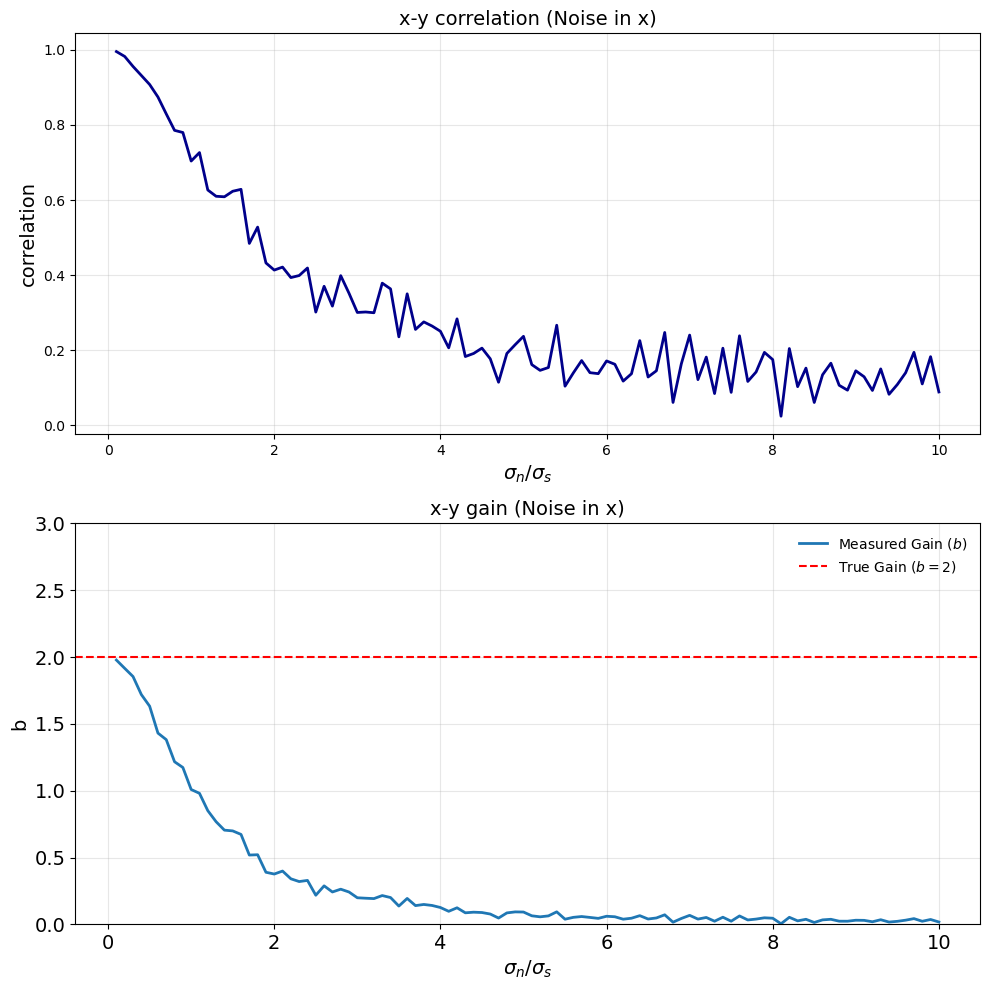

In [19]:
sigma_s = 10
npts = 365
z = np.random.normal(0,sigma_s, npts)

rho = np.zeros(100)
b = np.zeros(100)
noise_signal = np.zeros(100)

for j in range(1,101):
    sigma_n = j
    # ideal response, y
    y = 2*z
    # z plus noise, x
    x = z + np.random.normal(0, sigma_n, npts)
    # correlation
    rho[j-1] = np.corrcoef(x, y)[0, 1]
        
    # Regression (Gain b)
    # Using the standard formula: b = Cov(x,y) / Var(x)
    b[j-1] = np.sum(x * y) / np.sum(x**2)
    # noise-sginal ratio
    noise_signal[j-1] = sigma_n / sigma_s


# 5. Create Figure 7
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 10))

# correlation
ax1.plot(noise_signal, rho, linewidth=2, color='darkblue')
ax1.set_title('x-y correlation (Noise in x)', fontsize=14)
ax1.set_xlabel(r'$\sigma_n / \sigma_s$', fontsize=14)
ax1.set_ylabel('correlation', fontsize=14)
ax1.grid(True, alpha=0.3)

# gain (b)
ax2.plot(noise_signal, b, linewidth=2, label='Measured Gain ($b$)')
ax2.axhline(2.0, color='r', linestyle='--', label='True Gain ($b=2$)')
ax2.set_title('x-y gain (Noise in x)', fontsize=14)
ax2.set_xlabel(r'$\sigma_n / \sigma_s$', fontsize=14)
ax2.set_ylabel('b', fontsize=14)
ax2.set_ylim([0, 3])
ax2.grid(True, alpha=0.3)
ax2.tick_params(labelsize=14)
ax2.legend(frameon=False)

plt.tight_layout()
plt.show()



